# AIML Internship Task 3
## Model Validation, Overfitting Control & Hyperparameter Tuning

Dataset: California Housing Dataset

Objective:
- Detect overfitting
- Apply cross-validation
- Perform hyperparameter tuning
- Compare models
- Select best model

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV

from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge

from sklearn.tree import DecisionTreeRegressor

from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

In [2]:
housing = fetch_california_housing(as_frame=True)

df = housing.frame

print(df.shape)

df.head()

(20640, 9)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [9]:
df.isnull().sum()

MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

In [10]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


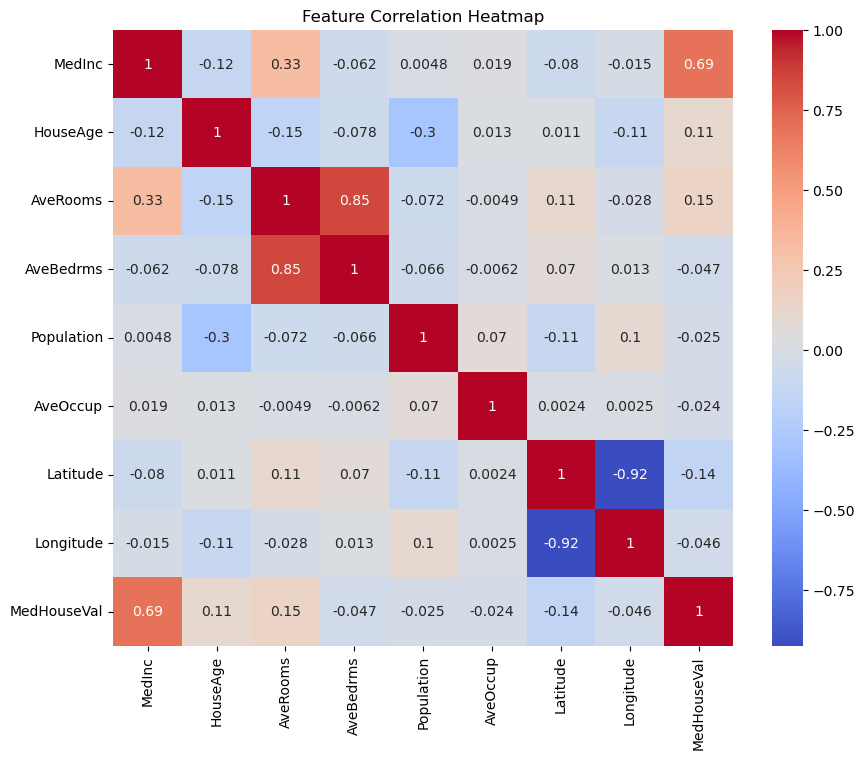

In [12]:
plt.figure(figsize=(10,8))

sns. heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Feature Correlation Heatmap")
plt.show()

In [13]:
X = df.drop("MedHouseVal", axis=1)

y = df["MedHouseVal"]

In [14]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

Training Shape: (16512, 8)
Testing Shape: (4128, 8)


In [16]:
tree = DecisionTreeRegressor(random_state=42)

tree.fit(X_train, y_train)

train_pred = tree.predict(X_train)

test_pred = tree.predict(X_test)

train_rmse = np.sqrt(
    mean_squared_error(y_train, train_pred)
)

test_rmse = np.sqrt(
    mean_squared_error(y_test, test_pred)
)

In [17]:
print("Train RMSE:", train_rmse)
print("Test RMSE:", test_rmse)

if test_rmse > train_rmse:
    print("Potential Overfitting Detected")
else:
    print("Model Generalizes Well")

Train RMSE: 3.218325866275131e-16
Test RMSE: 0.7030445773467542
Potential Overfitting Detected


In [18]:
cv_scores = cross_val_score(
    tree,
    X_scaled,
    y,
    cv=5,
    scoring="r2"
)

print("Cross Validation Scores:")
print(cv_scores)

print("\nAverage CV Score:", cv_scores.mean())

Cross Validation Scores:
[0.26650904 0.41457268 0.43886185 0.2386891  0.41977209]

Average CV Score: 0.35568094926127153


In [19]:
param_grid = {
    'max_depth':[3,5,7,10,15],
    'min_samples_split':[2,5,10],
    'min_samples_leaf':[1,2,4]
}

In [20]:
grid = GridSearchCV(
    DecisionTreeRegressor(random_state=42),
    param_grid,
    cv=5,
    scoring='r2'
)

grid.fit(X_train,y_train)

print("Best Parameters:")
print(grid.best_params_)

Best Parameters:
{'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 2}


In [21]:
best_tree = grid.best_estimator_

y_pred = best_tree.predict(X_test)

dt_rmse = np.sqrt(
    mean_squared_error(y_test,y_pred)
)

dt_r2 = r2_score(y_test,y_pred)

print("RMSE:",dt_rmse)
print("R2 Score:",dt_r2)

RMSE: 0.6389361233642388
R2 Score: 0.6884641539256358


In [22]:
lr = LinearRegression()

lr.fit(X_train,y_train)

lr_pred = lr.predict(X_test)

lr_rmse = np.sqrt(
    mean_squared_error(y_test,lr_pred)
)

lr_r2 = r2_score(y_test,lr_pred)

In [23]:
ridge = Ridge()

ridge.fit(X_train,y_train)

ridge_pred = ridge.predict(X_test)

ridge_rmse = np.sqrt(
    mean_squared_error(y_test,ridge_pred)
)

ridge_r2 = r2_score(y_test,ridge_pred)

In [24]:
results = pd.DataFrame({
    "Model":[
        "Linear Regression",
        "Ridge Regression",
        "Tuned Decision Tree"
    ],
    "RMSE":[
        lr_rmse,
        ridge_rmse,
        dt_rmse
    ],
    "R2 Score":[
        lr_r2,
        ridge_r2,
        dt_r2
    ]
})

results.sort_values(
    by="R2 Score",
    ascending=False
)

,Model,RMSE,R2 Score
2,Tuned Decision Tree,0.638936,0.688464
1,Ridge Regression,0.745554,0.575819
0,Linear Regression,0.745581,0.575788


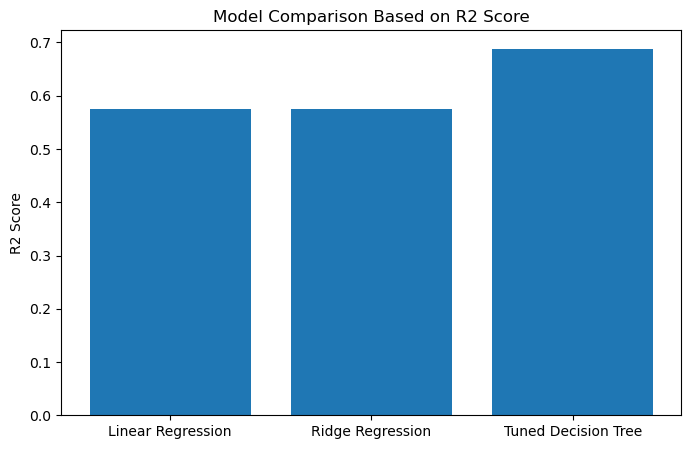

In [25]:
plt.figure(figsize=(8,5))

plt.bar(
    results["Model"],
    results["R2 Score"]
)

plt.title("Model Comparison Based on R2 Score")
plt.ylabel("R2 Score")

plt.show()

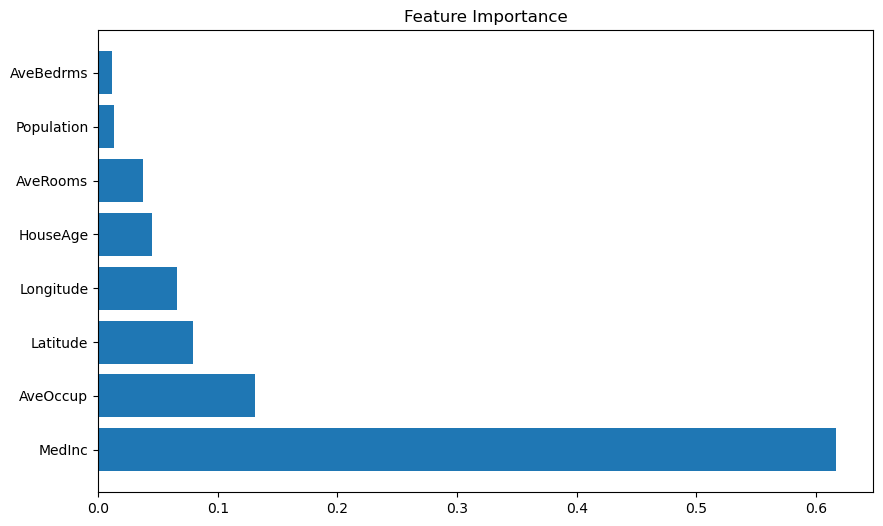

In [26]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": best_tree.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

plt.figure(figsize=(10,6))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.title("Feature Importance")
plt.show()